In [10]:
import cv2
import qrcode
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
BASE_DIR = Path("..")

GENERATED_QR_DIR = BASE_DIR / "sample_data" / "generated_qr"

INPUT_IMAGE_DIR = BASE_DIR / "sample_data" / "input_images"
OUTPUT_DIR = BASE_DIR / "app" / "outputs"

GENERATED_QR_DIR.mkdir(parents=True, exist_ok=True)
INPUT_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENERATED_QR_PATH = GENERATED_QR_DIR / "generated_qr.png"

print("Generated QR directory:", GENERATED_QR_DIR)
print("Input image directory:", INPUT_IMAGE_DIR)
print("Output directory:", OUTPUT_DIR)

Generated QR directory: ../sample_data/generated_qr
Input image directory: ../sample_data/input_images
Output directory: ../app/outputs


In [12]:
data = "https://github.com/SajjadHossainSoykot"

qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=10,
    border=4,
)

qr.add_data(data)
qr.make(fit=True)

qr_image = qr.make_image(
    fill_color="black",
    back_color="white"
)

qr_image.save(GENERATED_QR_PATH)

print("QR code generated successfully.")
print("Saved at:", GENERATED_QR_PATH)

QR code generated successfully.
Saved at: ../sample_data/generated_qr/generated_qr.png


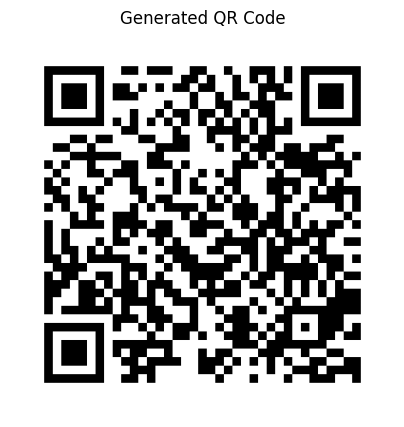

In [13]:
img = Image.open(GENERATED_QR_PATH)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Generated QR Code")
plt.axis("off")
plt.show()

In [22]:
# Read generated QR image using OpenCV

GENERATED_QR_PATH = GENERATED_QR_DIR / "generated_qr.png"
qr_cv_image = cv2.imread(str(GENERATED_QR_PATH))

# INPUT_IMAGE_PATH = INPUT_IMAGE_DIR / "invalid_qr.png"
# qr_cv_image = cv2.imread(str(INPUT_IMAGE_PATH))

if qr_cv_image is None:
    print("Could not read QR image.")
else:
    print("QR image loaded successfully.")
    print("Image shape:", qr_cv_image.shape)

QR image loaded successfully.
Image shape: (450, 450, 3)


In [23]:
# Decode QR code using OpenCV QRCodeDetector

detector = cv2.QRCodeDetector()

decoded_data, bbox, straight_qrcode = detector.detectAndDecode(qr_cv_image)

if decoded_data:
    print("QR code detected successfully.")
    print("Decoded data:")
    print(decoded_data)
else:
    print("No QR code detected.")

QR code detected successfully.
Decoded data:
https://github.com/SajjadHossainSoykot


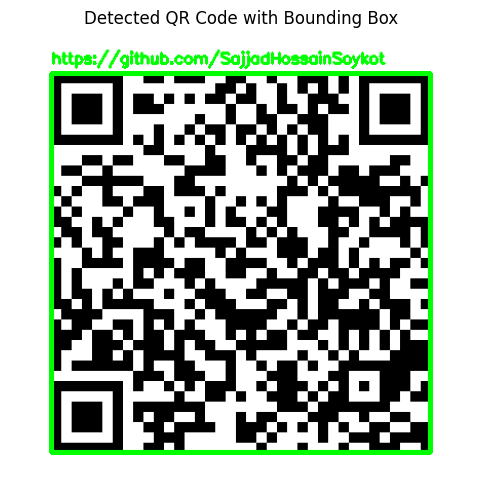

In [24]:
# Draw QR bounding box if detected

display_image = qr_cv_image.copy()

if bbox is not None:
    bbox = bbox.astype(int)

    for i in range(len(bbox[0])):
        point1 = tuple(bbox[0][i])
        point2 = tuple(bbox[0][(i + 1) % len(bbox[0])])
        cv2.line(display_image, point1, point2, (0, 255, 0), 3)

    if decoded_data:
        cv2.putText(
            display_image,
            decoded_data,
            (bbox[0][0][0], bbox[0][0][1] - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2,
        )

display_rgb = cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(display_rgb)
plt.title("Detected QR Code with Bounding Box")
plt.axis("off")
plt.show()

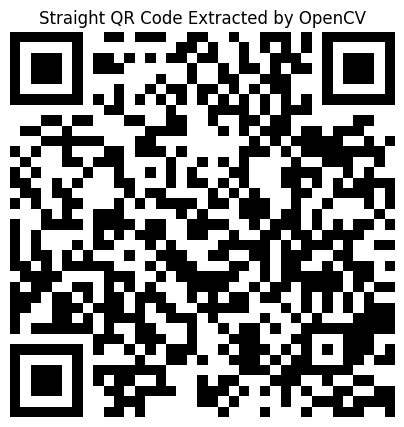

In [17]:
# Show straight QR code returned by OpenCV

if straight_qrcode is not None:
    plt.figure(figsize=(5, 5))
    plt.imshow(straight_qrcode, cmap="gray")
    plt.title("Straight QR Code Extracted by OpenCV")
    plt.axis("off")
    plt.show()
else:
    print("No straight QR output available.")